# 06 — Final Evaluation

The test set has not been touched since `03_split.ipynb` built it. Every
decision so far — architecture, augmentation, learning rate, which stage of
fine-tuning to stop at — was made using validation metrics only.

This notebook runs the test set **exactly once**, against **one** model,
chosen by validation performance recorded in `results/experiments.csv` — not
by re-deciding here. If you re-run this notebook after training a new model,
make sure that's actually intentional: re-touching the test set to compare
more candidates defeats the reason it was held out at all.

Order:
1. Pick the winning model from the experiment log
2. Load its checkpoint and run it on the test set, once
3. Recompute the majority-class and silhouette-only controls on this exact
   test set — the numbers the model actually has to beat
4. Confusion matrix and per-class report, with particular attention to
   glioma vs meningioma
5. Error analysis on the actual misclassified images

In [1]:
import csv, json
from pathlib import Path

import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms, models
from PIL import Image

from sklearn.metrics import (
    f1_score, confusion_matrix, classification_report,
)
from sklearn.linear_model import LogisticRegression
import cv2

torch.manual_seed(42)
np.random.seed(42)

DEVICE = (torch.device("mps") if torch.backends.mps.is_available()
          else torch.device("cuda") if torch.cuda.is_available()
          else torch.device("cpu"))
print("device:", DEVICE)

d = np.load("data/final_dataset.npz", allow_pickle=True)
X_train, y_train = d["X_train"], d["y_train"]   # only needed for the controls below
X_test,  y_test  = d["X_test"],  d["y_test"]
CLASSES = [str(c) for c in d["classes"]]

print(f"test set: {X_test.shape}")
print("classes :", CLASSES)

device: mps
test set: (886, 224, 224)
classes : ['glioma', 'meningioma', 'notumor', 'pituitary']


## 1. Which model actually won?

`results/experiments.csv` has one row per training run, each carrying its own
`best_val_f1`. Read the log rather than hardcoding which architecture to
load — the whole point of comparing on validation is that the log, not
memory of "which one felt better," decides.

In [2]:
with open("results/experiments.csv") as f:
    runs = list(csv.DictReader(f))

for r in runs:
    print(f"{r['model']:<22} val_f1={float(r['best_val_f1']):.4f}  "
          f"val_acc={float(r['best_val_acc']):.4f}  notes={r['notes']}")

winner = max(runs, key=lambda r: float(r["best_val_f1"]))
print(f"\nWinner by val macro-F1: {winner['model']}  (val_f1={float(winner['best_val_f1']):.4f})")

SmallCNN w32           val_f1=0.9595  val_acc=0.9573  notes=
ResNet18 pretrained    val_f1=0.9704  val_acc=0.9699  notes=two-stage freeze then finetune layer4

Winner by val macro-F1: ResNet18 pretrained  (val_f1=0.9704)


## 2. Load the winning checkpoint

Model classes and transforms are redefined here (not imported from 04/05) so
this notebook runs standalone, matching the pattern notebook 05 used for its
own copy of `run_epoch`.

For ResNet18, stage 1 (head-only) and stage 2 (fine-tuned) save to different
checkpoint files, and stage 2 doesn't always win — resolve which one actually
produced the logged `best_val_f1` by checking the per-epoch history rather
than assuming fine-tuning always helps.

In [3]:
class SmallCNN(nn.Module):
    """Must match 04_baselines_and_cnn.ipynb exactly, or load_state_dict fails."""
    def __init__(self, n_classes=4, in_ch=1, width=32, p_drop=0.3):
        super().__init__()

        def block(cin, cout):
            return nn.Sequential(
                nn.Conv2d(cin, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.Conv2d(cout, cout, 3, padding=1, bias=False),
                nn.BatchNorm2d(cout),
                nn.ReLU(inplace=True),
                nn.MaxPool2d(2),
            )

        w = width
        self.features = nn.Sequential(
            block(in_ch, w), block(w, w*2), block(w*2, w*4), block(w*4, w*8),
        )
        self.pool = nn.AdaptiveAvgPool2d(1)
        self.drop = nn.Dropout(p_drop)
        self.fc = nn.Linear(w*8, n_classes)

    def forward(self, x):
        x = self.features(x)
        x = self.pool(x).flatten(1)
        return self.fc(self.drop(x))


def build_resnet(n_classes=4):
    """Matches 05_transfer_learning.ipynb. freeze state doesn't matter for
    inference — only the architecture (fc replaced) needs to match."""
    m = models.resnet18(weights=None)   # weights loaded from our checkpoint, not ImageNet
    m.fc = nn.Linear(m.fc.in_features, n_classes)
    return m


if winner["model"] == "SmallCNN w32":
    MODEL_KIND = "cnn"
    model = SmallCNN(n_classes=len(CLASSES)).to(DEVICE)
    model.load_state_dict(torch.load("checkpoints/best.pt", map_location=DEVICE))

elif winner["model"] == "ResNet18 pretrained":
    MODEL_KIND = "resnet"
    # Figure out whether stage 1 or stage 2 produced the winning epoch.
    with open("results/resnet18_history.json") as f:
        hist = json.load(f)
    STAGE1_EPOCHS = 8   # matches notebook 05's stage 1 length
    best_epoch_idx = int(np.argmax(hist["va_f1"]))
    tag = "resnet18_stage1" if best_epoch_idx < STAGE1_EPOCHS else "resnet18_finetuned"
    print(f"Best epoch was #{best_epoch_idx + 1} -> loading checkpoints/{tag}.pt")

    model = build_resnet(len(CLASSES)).to(DEVICE)
    model.load_state_dict(torch.load(f"checkpoints/{tag}.pt", map_location=DEVICE))

else:
    raise ValueError(f"Unrecognized model name in log: {winner['model']}")

model.eval()
print(f"\nLoaded {winner['model']} ({MODEL_KIND}), val_f1={float(winner['best_val_f1']):.4f}")

Best epoch was #16 -> loading checkpoints/resnet18_finetuned.pt

Loaded ResNet18 pretrained (resnet), val_f1=0.9704


## 3. Test-set dataloader

Transform depends on which model won: the CNN expects single-channel input
normalized with this dataset's own stats, ResNet expects 3-channel input
normalized with ImageNet stats. No augmentation — this is evaluation, run
once.

In [4]:
class BrainMRI(Dataset):
    def __init__(self, X, y, transform):
        self.X, self.y, self.transform = X, y, transform

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        img = Image.fromarray((self.X[i] * 255).astype(np.uint8))
        return self.transform(img), int(self.y[i])


if MODEL_KIND == "cnn":
    with open("data/norm_stats.json") as f:
        stats = json.load(f)
    MEAN, STD = stats["mean"], stats["std"]
    test_tf = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize([MEAN], [STD]),
    ])
else:
    IMAGENET_MEAN = [0.485, 0.456, 0.406]
    IMAGENET_STD  = [0.229, 0.224, 0.225]
    test_tf = transforms.Compose([
        transforms.Grayscale(num_output_channels=3),
        transforms.ToTensor(),
        transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
    ])

test_ds = BrainMRI(X_test, y_test, test_tf)
test_dl = DataLoader(test_ds, batch_size=32, shuffle=False, num_workers=0)
print(f"test batches: {len(test_dl)}")

test batches: 28


## 4. Run the test set — once

Also keeps each image's index so misclassified examples can be traced back
to the actual array for the error-analysis grid in section 7.

In [5]:
all_preds, all_trues, all_probs = [], [], []

with torch.no_grad():
    for xb, yb in test_dl:
        xb = xb.to(DEVICE)
        out = model(xb)
        probs = F.softmax(out, dim=1).cpu().numpy()
        all_probs.append(probs)
        all_preds.append(out.argmax(1).cpu().numpy())
        all_trues.append(yb.numpy())

y_pred = np.concatenate(all_preds)
y_true = np.concatenate(all_trues)
y_prob = np.concatenate(all_probs)

test_acc = (y_pred == y_true).mean()
test_f1 = f1_score(y_true, y_pred, average="macro")

print(f"TEST accuracy  : {test_acc:.4f}")
print(f"TEST macro-F1  : {test_f1:.4f}")
print(f"(val macro-F1 was {float(winner['best_val_f1']):.4f} — a big gap here "
      f"would mean val stopped being a reliable proxy for test)")

TEST accuracy  : 0.9233
TEST macro-F1  : 0.8945
(val macro-F1 was 0.9704 — a big gap here would mean val stopped being a reliable proxy for test)


## 5. Recompute the controls on THIS test set

Same reasoning as notebook 04 §2: the clean test set has a different class
distribution than the mixed sample controls were originally computed on
(`notumor` lost most of its images to leakage removal). These need to be
recomputed here, on the same 886 images the model was just scored on, or the
comparison is meaningless.

In [6]:
print("Test set class distribution:")
for i, cls in enumerate(CLASSES):
    n = int((y_test == i).sum())
    print(f"  {cls:<14} {n:>4}  ({100*n/len(y_test):>5.1f}%)")

maj = np.bincount(y_test).max() / len(y_test)
print(f"\nMajority-class baseline: {maj:.3f}")


def silhouette_border(arr):
    a = cv2.resize(arr, (32, 32), interpolation=cv2.INTER_AREA)
    a = (a > 0.1).astype(np.float32)
    return np.concatenate([a[:3].ravel(), a[-3:].ravel(),
                           a[3:-3, :3].ravel(), a[3:-3, -3:].ravel()])

Xs_tr = np.stack([silhouette_border(a) for a in X_train])
Xs_te = np.stack([silhouette_border(a) for a in X_test])
shape_clf = LogisticRegression(max_iter=2000).fit(Xs_tr, y_train)
shape_acc = shape_clf.score(Xs_te, y_test)

print(f"Silhouette-only control: {shape_acc:.3f}")
print(f"\n{'':<28}{'accuracy':>10}")
print(f"{'majority baseline':<28}{maj:>10.3f}")
print(f"{'silhouette-only control':<28}{shape_acc:>10.3f}")
print(f"{winner['model']:<28}{test_acc:>10.3f}")

Test set class distribution:
  glioma          314  ( 35.4%)
  meningioma      227  ( 25.6%)
  notumor          47  (  5.3%)
  pituitary       298  ( 33.6%)

Majority-class baseline: 0.354
Silhouette-only control: 0.484

                              accuracy
majority baseline                0.354
silhouette-only control          0.484
ResNet18 pretrained              0.923


If `test_acc` isn't comfortably above the silhouette control, the model may
be leaning on framing/field-of-view artifacts rather than tumor anatomy —
the confusion matrix and error grid below are where that would actually show
up, not just in this one number.

## 6. Confusion matrix and per-class report

Glioma vs meningioma gets called out specifically per notebook 05's note:
that pair has the least available shortcut (no framing/silhouette signal
distinguishes them the way it can for `notumor`), so their mutual confusion
rate is a more honest signal of genuine feature learning than the headline
accuracy.

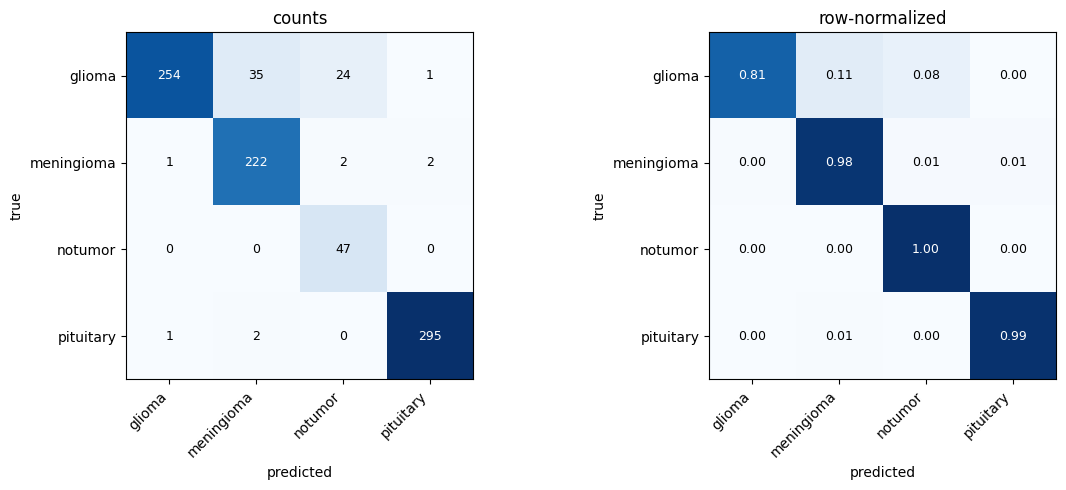

glioma predicted as meningioma:     35 / 314 (11.1%)
meningioma predicted as glioma:     1 / 227 (0.4%)


In [7]:
cm = confusion_matrix(y_true, y_pred)
cm_norm = cm.astype(np.float64) / cm.sum(axis=1, keepdims=True)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
for ax, mat, title, fmt in [(axes[0], cm, "counts", "d"),
                            (axes[1], cm_norm, "row-normalized", ".2f")]:
    im = ax.imshow(mat, cmap="Blues")
    ax.set_xticks(range(len(CLASSES))); ax.set_xticklabels(CLASSES, rotation=45, ha="right")
    ax.set_yticks(range(len(CLASSES))); ax.set_yticklabels(CLASSES)
    ax.set_xlabel("predicted"); ax.set_ylabel("true"); ax.set_title(title)
    for i in range(len(CLASSES)):
        for j in range(len(CLASSES)):
            val = mat[i, j]
            text = f"{val:{fmt}}"
            ax.text(j, i, text, ha="center", va="center",
                    color="white" if val > mat.max()/2 else "black", fontsize=9)
plt.tight_layout()
Path("figures").mkdir(exist_ok=True)
fig.savefig("figures/final_confusion_matrix.png", dpi=150, bbox_inches="tight")
plt.show()

gi, mi = CLASSES.index("glioma"), CLASSES.index("meningioma")
print(f"glioma predicted as meningioma:     {cm[gi, mi]} / {cm[gi].sum()} "
      f"({100*cm[gi, mi]/cm[gi].sum():.1f}%)")
print(f"meningioma predicted as glioma:     {cm[mi, gi]} / {cm[mi].sum()} "
      f"({100*cm[mi, gi]/cm[mi].sum():.1f}%)")

In [8]:
report_str = classification_report(y_true, y_pred, target_names=CLASSES, digits=3)
print(report_str)

report_dict = classification_report(y_true, y_pred, target_names=CLASSES,
                                    digits=3, output_dict=True)
Path("results").mkdir(exist_ok=True)
with open("results/final_classification_report.json", "w") as f:
    json.dump(report_dict, f, indent=2)

              precision    recall  f1-score   support

      glioma      0.992     0.809     0.891       314
  meningioma      0.857     0.978     0.914       227
     notumor      0.644     1.000     0.783        47
   pituitary      0.990     0.990     0.990       298

    accuracy                          0.923       886
   macro avg      0.871     0.944     0.895       886
weighted avg      0.938     0.923     0.924       886



## 7. Error analysis

Look at actual misclassified images rather than stopping at the numbers
above. Glioma/meningioma confusions get their own row since that's the pair
worth understanding, not just measuring.

In [9]:
wrong_idx = np.where(y_pred != y_true)[0]
print(f"{len(wrong_idx)} / {len(y_true)} misclassified ({100*len(wrong_idx)/len(y_true):.1f}%)")

gm_confusions = [i for i in wrong_idx
                if {y_true[i], y_pred[i]} == {gi, mi}]
other_confusions = [i for i in wrong_idx if i not in set(gm_confusions)]

print(f"  of which glioma<->meningioma: {len(gm_confusions)}")
print(f"  of which other:               {len(other_confusions)}")

68 / 886 misclassified (7.7%)
  of which glioma<->meningioma: 36
  of which other:               32


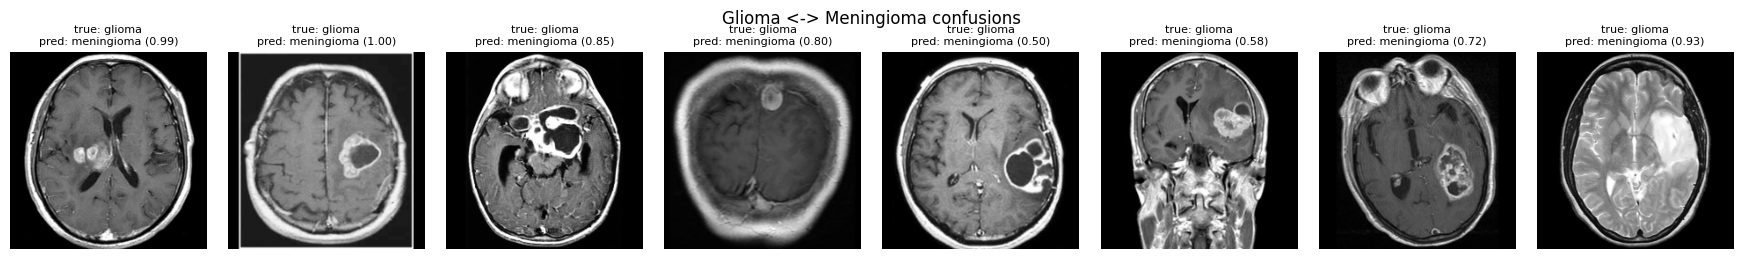

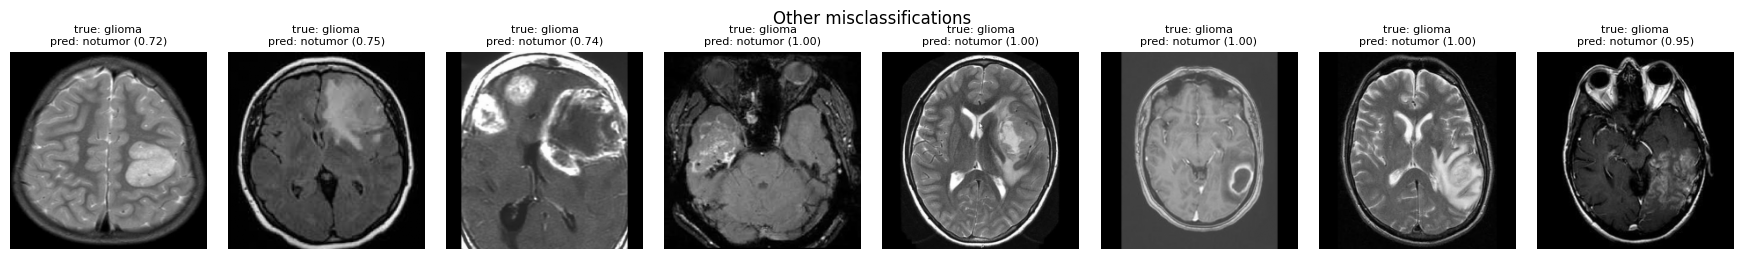

In [10]:
def show_examples(idxs, title, n=8):
    idxs = idxs[:n]
    if not idxs:
        print(f"{title}: none")
        return
    fig, axes = plt.subplots(1, len(idxs), figsize=(2.2*len(idxs), 2.6))
    axes = np.atleast_1d(axes)
    for ax, i in zip(axes, idxs):
        ax.imshow(X_test[i], cmap="gray")
        conf = y_prob[i, y_pred[i]]
        ax.set_title(f"true: {CLASSES[y_true[i]]}\npred: {CLASSES[y_pred[i]]} ({conf:.2f})",
                    fontsize=8)
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout(); plt.show()

show_examples(gm_confusions, "Glioma <-> Meningioma confusions")
show_examples(other_confusions, "Other misclassifications")

### What to record here

Same discipline as notebook 01's manual-inspection step — answer these in
your own words, it becomes part of the writeup:

1. Are the glioma/meningioma confusions genuinely ambiguous-looking to your
   own eye, or does the model seem to be making an obviously wrong call?
2. Are the *other* misclassifications concentrated in one class, or spread
   evenly? A concentration usually means a systematic issue (framing,
   image quality) rather than random noise.
3. Are the model's confidence scores on wrong predictions notably lower than
   on correct ones (a sign it's meaningfully uncertain rather than
   confidently wrong)?

_Findings:_

1. 
2. 
3. 

## 8. Save final results

In [11]:
final_results = {
    "winning_model": winner["model"],
    "val_f1": float(winner["best_val_f1"]),
    "test_acc": float(test_acc),
    "test_macro_f1": float(test_f1),
    "majority_baseline": float(maj),
    "silhouette_control": float(shape_acc),
    "n_test_images": int(len(y_test)),
    "glioma_meningioma_confusions": len(gm_confusions),
    "other_confusions": len(other_confusions),
}

with open("results/final_test_results.json", "w") as f:
    json.dump(final_results, f, indent=2)

print("Saved results/final_test_results.json")
print("Saved results/final_classification_report.json")
print("Saved figures/final_confusion_matrix.png")
for k, v in final_results.items():
    print(f"  {k:<30}{v}")

Saved results/final_test_results.json
Saved results/final_classification_report.json
Saved figures/final_confusion_matrix.png
  winning_model                 ResNet18 pretrained
  val_f1                        0.9704
  test_acc                      0.9232505643340858
  test_macro_f1                 0.8945186340820981
  majority_baseline             0.3544018058690745
  silhouette_control            0.48419864559819414
  n_test_images                 886
  glioma_meningioma_confusions  36
  other_confusions              32
